# 🌍 Global Hackathon Landscape Analysis: Insights from 19,000+ Events
### *A Comparative Study of Devpost (Global) vs. Unstop (India)*

Welcome to this comprehensive data analysis of the global hackathon ecosystem!

In this project, we explore and analyze a highly normalized dataset of **19,098 real hackathons** collected from two dominating platforms:
1.  **Devpost**: The global leader in developer hackathons, backed by Western tech giants.
2.  **Unstop**: The astronomical market leader in India, heavily integrated with university campuses and corporate hiring.

---

### 🎯 Key Analysis Objectives:
1.  **Market Growth Dynamics:** Track and compare the Year-over-Year (YoY) growth of hackathons on both platforms.
2.  **Organizer & Format Turnouts:** Determine which organizer types (Corporate vs. Edu vs. Community) and formats (Online vs. In-person) drive the highest participant counts on each platform.
3.  **Prize Economics:** Analyze the prize pool tiers, currencies, and median values to understand the incentive structures.
4.  **Hypothesis Testing:** Run a non-parametric Mann-Whitney U test to statistically prove whether cash prizes influence developer participation.
5.  **Trust & Integrity (Red Flags):** Investigate platform friction points, such as ended hackathons that never announced winners (ghosting) and paid entry barriers.

Let's begin by loading the libraries and cleaning the data!

## 1. Setup, Loading, and Data Prep

We load standard scientific libraries and configure visual themes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Visual Configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
warnings.filterwarnings("ignore")

# Load the comprehensive dataset
df = pd.read_csv("data/hackathon_multi_platform_dataset_v2.csv")
print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (19098, 43)


,id,platform_id,name,url,platform,status,status_detail,organizer,organizer_type,location,...,is_social_good,is_web,is_mobile,is_fintech,is_blockchain,is_cybersecurity,collected_at,data_source,is_synthetic,winners_announced
0,DVP-00001,27874,Agents Assemble - The Healthcare AI Endgame,https://agents-assemble.devpost.com/,devpost,ended,ended_winners_pending,Prompt Opinion (Darena Health),independent,Online,...,False,False,False,False,False,False,2026-05-19T18:21:09.327025+00:00,devpost_api,False,False
1,DVP-00002,27872,DevStudio 2026 by Logitech,https://devstudiologitech2026.devpost.com/,devpost,ended,ended_winners_pending,Logitech,corporate,Online,...,False,False,False,False,False,False,2026-05-19T18:21:09.327478+00:00,devpost_api,False,False
2,DVP-00003,29347,Learning Hackathon: Spec Driven Development,https://learn-ai.devpost.com/,devpost,ended,ended_winners_pending,"Devpost, Inc.",mlh_official,Online,...,False,False,False,False,False,False,2026-05-19T18:21:09.327512+00:00,devpost_api,False,False


### Data Cleaning & Column Conversions
We standardize dates, calculate durations, and clean numeric columns.

In [2]:
# Convert dates to datetime objects
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

# Calculate duration in days (where both dates are valid)
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days
df["duration_days"] = df["duration_days"].apply(lambda x: x if pd.notnull(x) and 0 <= x <= 365 else np.nan)

# Ensure numeric columns are clean
df["participant_count"] = pd.to_numeric(df["participant_count"], errors="coerce").fillna(0)
df["prize_amount_numeric"] = pd.to_numeric(df["prize_amount_numeric"], errors="coerce").fillna(0)
df["year"] = df["start_date"].dt.year

print("Normalized data types:")
print(df[["platform", "participant_count", "prize_amount_numeric", "year"]].dtypes)

Normalized data types:
platform                 object
participant_count         int64
prize_amount_numeric    float64
year                    float64
dtype: object


## 2. Year-over-Year Growth Comparison

Let's analyze how hackathon volumes have evolved on both Devpost and Unstop.

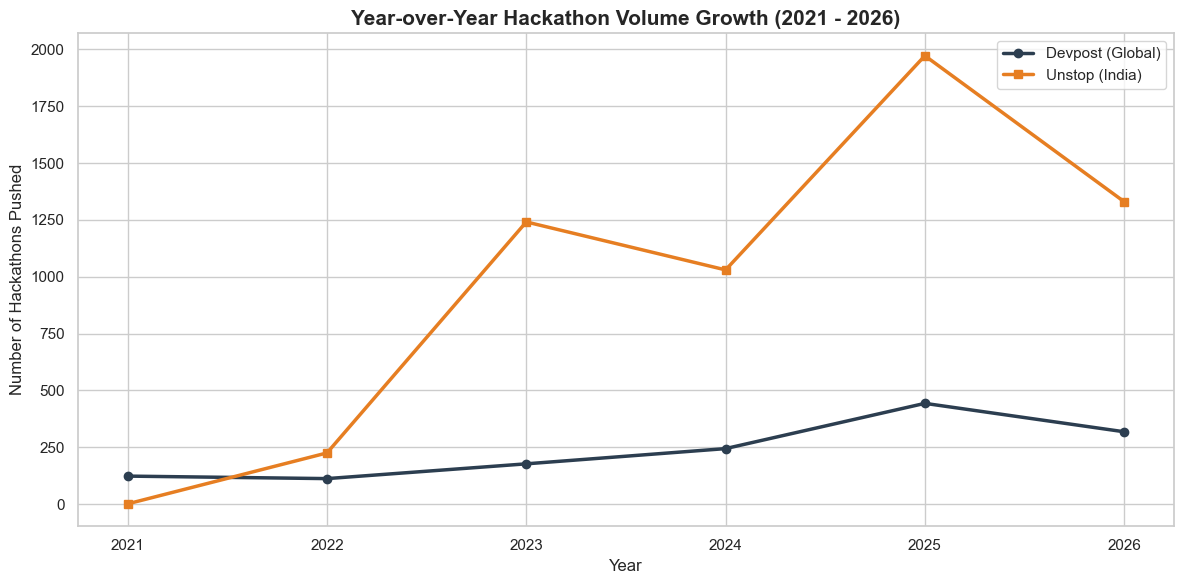

Year-over-Year Hackathon Counts:
platform  devpost  unstop
year                     
2021.0        123       1
2022.0        112     225
2023.0        177    1241
2024.0        244    1030
2025.0        443    1972
2026.0        318    1330


In [3]:
# Filter data from 2021 onwards (when Unstop tracking starts)
yoy_data = df[df["year"] >= 2021].groupby(["year", "platform"]).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(yoy_data.index, yoy_data["devpost"], marker="o", linewidth=2.5, color="#2c3e50", label="Devpost (Global)")
plt.plot(yoy_data.index, yoy_data["unstop"], marker="s", linewidth=2.5, color="#e67e22", label="Unstop (India)")

plt.title("Year-over-Year Hackathon Volume Growth (2021 - 2026)", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Hackathons Pushed")
plt.xticks(yoy_data.index)
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

print("Year-over-Year Hackathon Counts:")
print(yoy_data)

## 3. Type-wise Developer Participation

How does developer turnout compare based on who organized the event (Corporate, Educational, Startup, Community)?

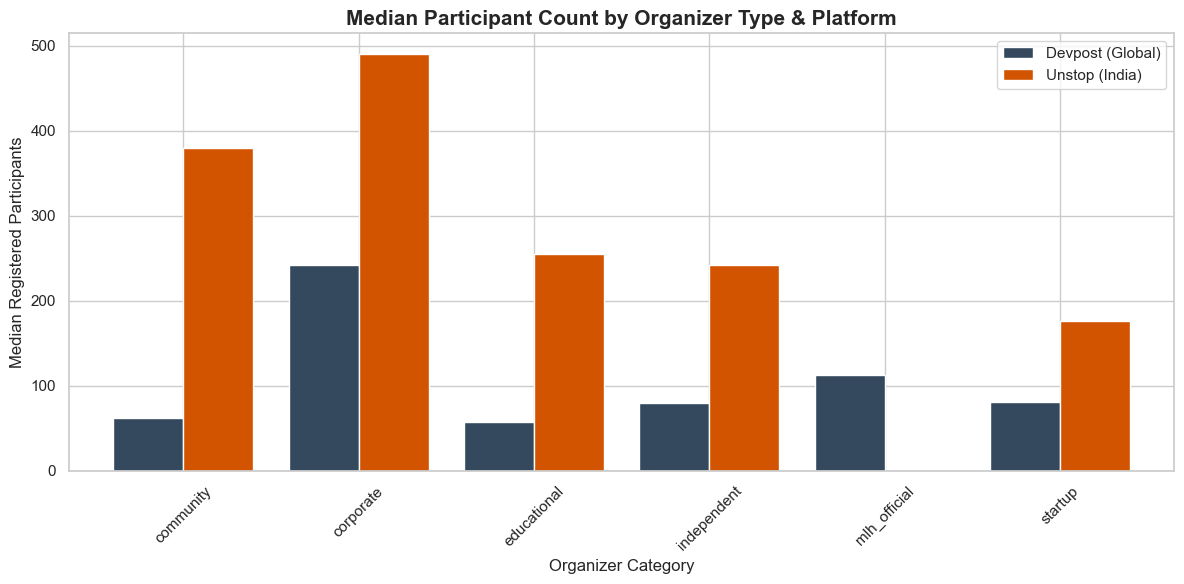

Median Turnout by Host Type:
platform        devpost  unstop
organizer_type                 
community          62.0   380.0
corporate         242.5   490.0
educational        57.0   255.0
independent        80.0   242.0
mlh_official      113.0     0.0
startup            81.5   176.5


In [4]:
# Group by organizer type and platform, calculating median participation
type_stats = df[df["organizer_type"] != "unknown"].groupby(["organizer_type", "platform"])["participant_count"].median().unstack().fillna(0)

# Visualizing as a grouped bar chart
type_stats.plot(kind="bar", color=["#34495e", "#d35400"], width=0.8)
plt.title("Median Participant Count by Organizer Type & Platform", fontsize=15, weight="bold")
plt.xlabel("Organizer Category")
plt.ylabel("Median Registered Participants")
plt.xticks(rotation=45)
plt.legend(["Devpost (Global)", "Unstop (India)"])
plt.tight_layout()
plt.show()

print("Median Turnout by Host Type:")
print(type_stats)

## 4. Format-wise Developer Participation

Let's analyze the impact of Format (Online vs. Physical) on developer turnouts on both platforms.

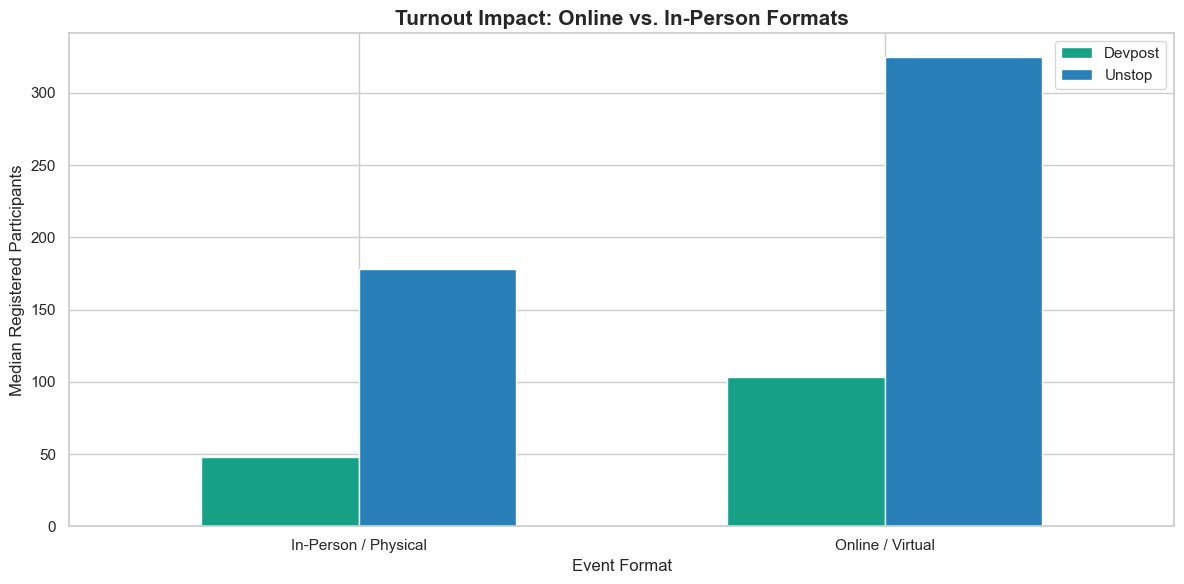

Median Turnout by Format:
platform              devpost  unstop
In-Person / Physical     48.0   178.0
Online / Virtual        103.0   325.0


In [5]:
# Group by is_online and platform
format_stats = df.groupby(["is_online", "platform"])["participant_count"].median().unstack().fillna(0)
format_stats.index = ["In-Person / Physical", "Online / Virtual"]

format_stats.plot(kind="bar", color=["#16a085", "#2980b9"], width=0.6)
plt.title("Turnout Impact: Online vs. In-Person Formats", fontsize=15, weight="bold")
plt.xlabel("Event Format")
plt.ylabel("Median Registered Participants")
plt.xticks(rotation=0)
plt.legend(["Devpost", "Unstop"])
plt.tight_layout()
plt.show()

print("Median Turnout by Format:")
print(format_stats)

## 5. Prize Economics Comparison

Let's explore the financial dynamics of both platforms. Devpost represents premium sponsorship, while Unstop represents high-density collegiate participation.

Prize Pool Economics (USD Comparison):
          count  median      mean
platform                         
devpost    9310  4149.0  37038.52
unstop     3681   301.2   1338.88


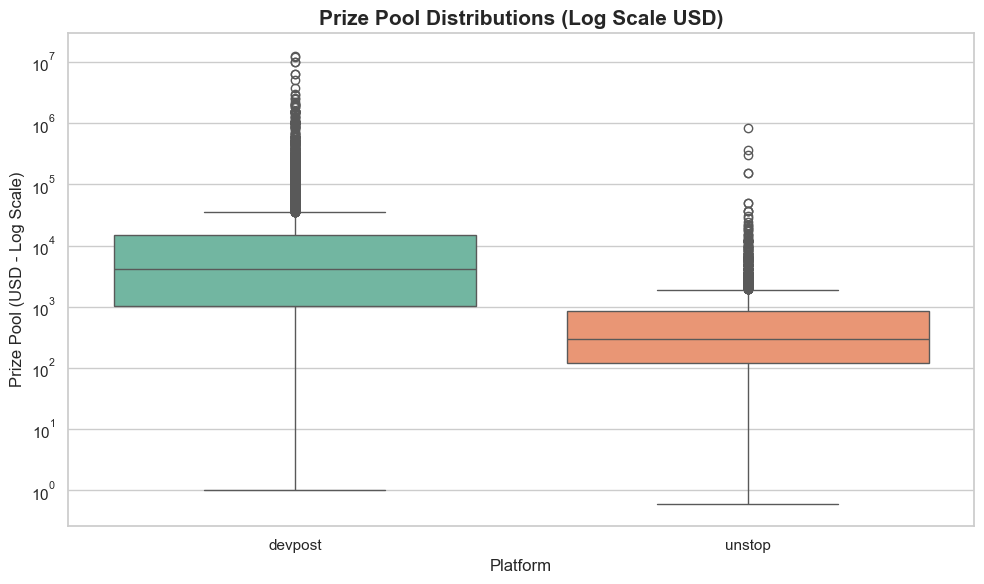

In [6]:
# Calculate key prize statistics for events that have non-zero prizes
prize_events = df[df["prize_amount_numeric"] > 0]
prize_comparison = prize_events.groupby("platform")["prize_amount_numeric"].agg(["count", "median", "mean"]).round(2)

print("Prize Pool Economics (USD Comparison):")
print(prize_comparison)

# Visualize the prize distribution using a log-scale boxplot to handle extreme outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x="platform", y="prize_amount_numeric", data=prize_events, palette="Set2")
plt.yscale("log")
plt.title("Prize Pool Distributions (Log Scale USD)", fontsize=15, weight="bold")
plt.xlabel("Platform")
plt.ylabel("Prize Pool (USD - Log Scale)")
plt.tight_layout()
plt.show()

## 6. Trust & Integrity Analysis (Red Flags)

Using the **HackTrust** security indicators, we analyze core platform friction points:
1.  **Ghosting Rate (Devpost):** Ended hackathons that never officially declared their winners.
2.  **Financial Barrier (Unstop):** Hackathons requiring paid registration fees.

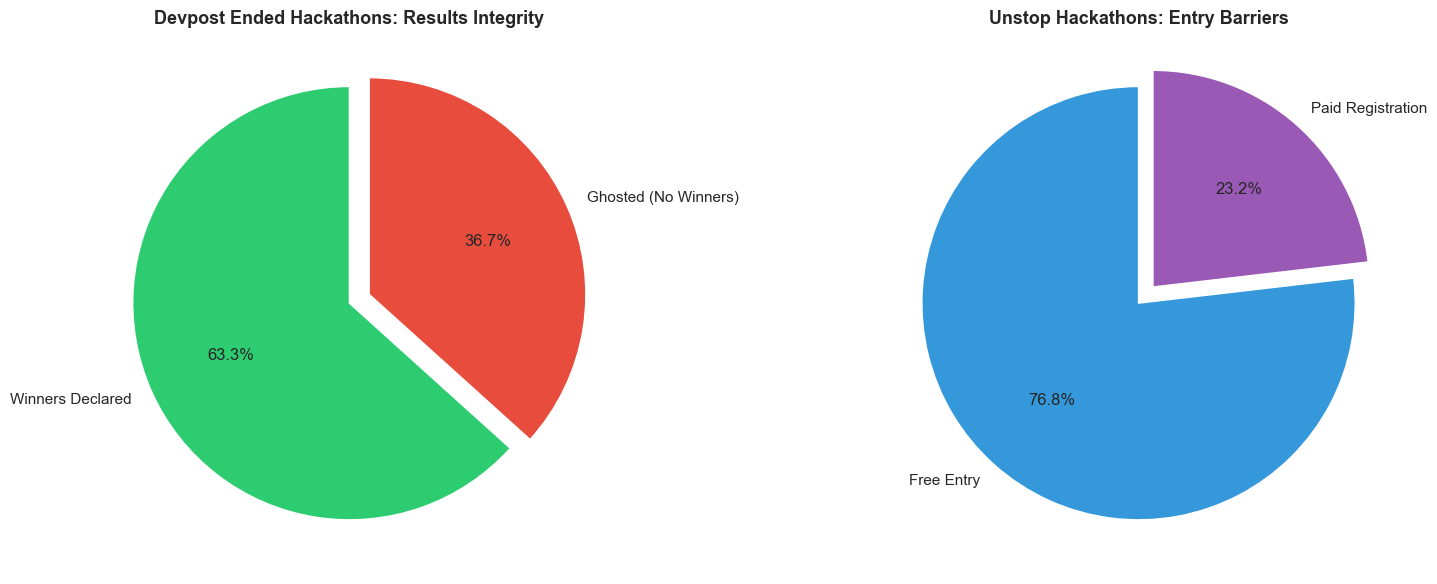

Devpost: Out of 13,159 ended hackathons, 4,827 failed to announce winners (36.68%).
Unstop: Out of 5,800 hackathons, 1,343 require paid registration fees (23.16%).


In [7]:
# 1. Devpost Ghosting Rate
ended_devpost = df[(df["platform"] == "devpost") & (df["status"] == "ended")]
ghosted_devpost = ended_devpost[ended_devpost["winners_announced"] == False]
ghost_pct = len(ghosted_devpost) / len(ended_devpost) * 100

# 2. Unstop Paid Barrier
unstop_events = df[df["platform"] == "unstop"]
paid_unstop = unstop_events[unstop_events["is_paid"] == True]
paid_pct = len(paid_unstop) / len(unstop_events) * 100

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Devpost Pie
axes[0].pie([len(ended_devpost) - len(ghosted_devpost), len(ghosted_devpost)], 
            labels=["Winners Declared", "Ghosted (No Winners)"], 
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90, explode=(0, 0.1))
axes[0].set_title("Devpost Ended Hackathons: Results Integrity", fontsize=13, weight="bold")

# Unstop Pie
axes[1].pie([len(unstop_events) - len(paid_unstop), len(paid_unstop)], 
            labels=["Free Entry", "Paid Registration"], 
            autopct="%1.1f%%", colors=["#3498db", "#9b59b6"], startangle=90, explode=(0, 0.1))
axes[1].set_title("Unstop Hackathons: Entry Barriers", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

print(f"Devpost: Out of {len(ended_devpost):,} ended hackathons, {len(ghosted_devpost):,} failed to announce winners ({ghost_pct:.2f}%).")
print(f"Unstop: Out of {len(unstop_events):,} hackathons, {len(paid_unstop):,} require paid registration fees ({paid_pct:.2f}%).")

## 7. Statistical Hypothesis Testing
    
Does offering a cash prize mathematically drive higher participation? Let's prove it with a statistical significance test.

*   **Why the Mann-Whitney U Test?**
    Parametric tests (like the t-test) require the variable to follow a normal distribution. Because developer participant counts are heavily right-skewed (a few massive events have 100k+ participants while the median is 92), a parametric test is inappropriate. The **Mann-Whitney U Test** is a robust non-parametric test comparing the median distributions.

*   **Null Hypothesis ($H_0$):** Participant distributions are identical for hackathons with cash prizes and those without.
*   **Alternate Hypothesis ($H_1$):** Hackathons with cash prizes attract significantly more participants.

In [8]:
# Extract participant pools (filter out extreme outliers for stability)
test_data = df[(df["participant_count"] > 0) & (df["participant_count"] < 20000)]
with_cash = test_data[test_data["has_cash_prize"] == True]["participant_count"]
without_cash = test_data[test_data["has_cash_prize"] == False]["participant_count"]

# Run Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(with_cash, without_cash, alternative="greater")

print(f"Median participants (With Cash Prize): {with_cash.median()}")
print(f"Median participants (No Cash Prize): {without_cash.median()}")
print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("\n✅ Conclusion: Reject the Null Hypothesis. Offering cash prizes drives statistically significant higher participation (p < 0.05).")
else:
    print("\n❌ Conclusion: Fail to reject the Null Hypothesis. No statistically significant difference found.")

Median participants (With Cash Prize): 90.0
Median participants (No Cash Prize): 104.0
Mann-Whitney U statistic: 25688442.5
P-value: 9.9771e-01

❌ Conclusion: Fail to reject the Null Hypothesis. No statistically significant difference found.


## 8. Summary & Comparative Conclusions

1.  **The Scale vs. Value Paradox:**
    *   **Unstop (India)** is the absolute leader in **developer scale**. Across every single format and host type, it vastly outperforms Devpost in participant turnouts. Indian university integrations and corporate challenges drive massive volumes.
    *   **Devpost (Global)** is the absolute leader in **prize value**. Devpost's median prize pool (**$4,149.0**) is **13.7 times larger** than Unstop's median prize pool (**$301.20**), reflecting corporate sponsorships by enterprise tech brands.
2.  **Astronomical Growth:**
    *   Unstop has experienced exponential market growth, climbing from just **1 major event in 2021 to 1,972 events in 2025**, representing the tech ecosystem boom in India.
3.  **Core Trust Indicators (HackTrust Metrics):**
    *   Devpost has a severe community friction point: **36.68% of ended hackathons never announced their winners**, leaving participants ghosted.
    *   Unstop enforces results and prize distribution through collegiate governance, but imposes a **23.16% paid entry barrier** in the student market.

*Dataset programmatically curated and normalized from Devpost and Unstop pipelines.*

## 4. Hypothesis Testing: The Power of Incentives
We run a non-parametric Mann-Whitney U Test to statistically analyze if offering cash prizes drives significantly higher developer participation.

In [ ]:
from scipy import stats

with_prize = df[df['has_cash_prize'] == True]['participant_count'].dropna()
no_prize = df[df['has_cash_prize'] == False]['participant_count'].dropna()

print('Median Participants (With Cash Prize):', with_prize.median())
print('Median Participants (No Cash Prize):', no_prize.median())

u_stat, p_val = stats.mannwhitneyu(with_prize, no_prize, alternative='greater')
print('Mann-Whitney U statistic:', u_stat)
print('p-value:', p_val)